# `AirPassengers` 데이터셋 예측 (ARIMA, ARCH & GARCH)

In [25]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # acf plot 및 pacf plot을 그리기 위한 라이브러리
from statsmodels.tsa.arima_model import ARIMA # ARIMA 모델
import pmdarima as pm # Auto ARIMA 모델

import warnings
warnings.filterwarnings("ignore")

## 데이터 불러오기

In [4]:
ap = pd.read_csv('/Users/chankyulee/Desktop/ModuLABS/05_TimeSeries/Data/AirPassengers.csv')

# Month 컬럼은 역시 필요가 없으니 삭제
ap.drop('Month', axis = 1, inplace = True)
ap

,#Passengers
0,112
1,118
2,132
3,129
4,121
...,...
139,606
140,508
141,461
142,390


## 데이터 확인

정상성을 가지고 있는지 시각화를 통해 확인 -> 없으니까 Log Transformationd을 통해 분산을 일정하게 조절

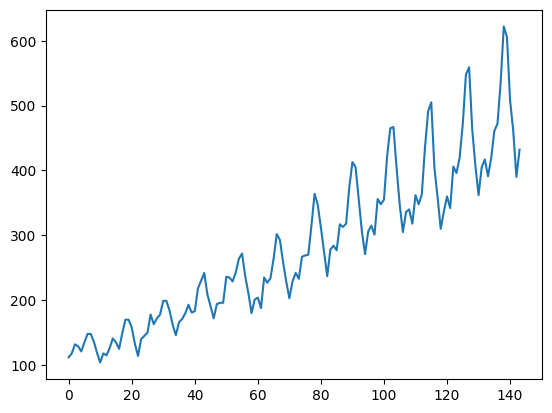

In [5]:
plt.plot(ap)
plt.show()

## 분산을 일정하게 - Log Transformation

In [7]:
ap_transformed = np.log(ap)
ap_transformed

,#Passengers
0,4.718499
1,4.770685
2,4.882802
3,4.859812
4,4.795791
...,...
139,6.406880
140,6.230481
141,6.133398
142,5.966147


ACF, PACF 확인
- ACF의 경우 점차 감소하는 모양을 가지고, 꽤 긴 시차만큼 자기상관이 유효함.
- PACF의 경우 자기자신(1)과 12에서 유효함.

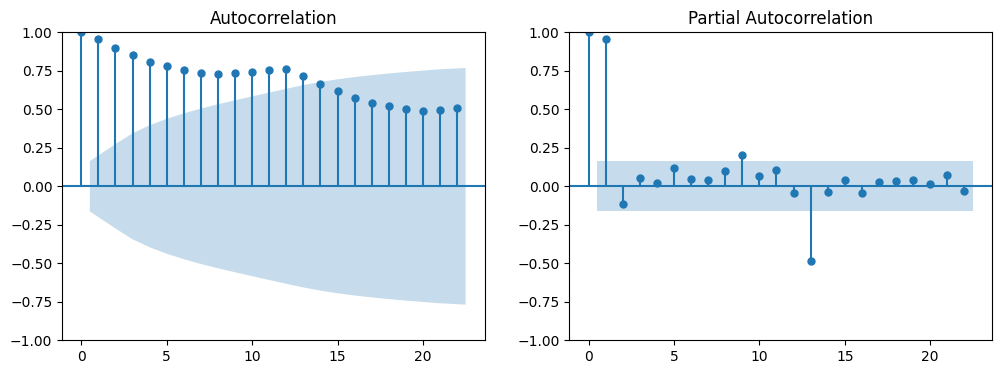

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# ACF
plot_acf(ap_transformed, ax = axes[0])

# PACF
plot_pacf(ap_transformed, ax = axes[1])
plt.show()

## 차분을 통해 분석

추세가 남아있는 데이터라서 위와 같은 형태를 띠므로, 차분을 통해 추세를 제거

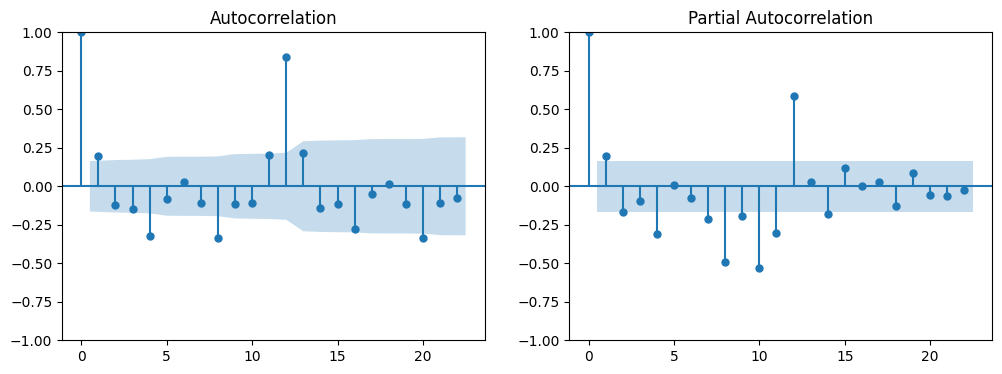

In [18]:
ap_diff = ap_transformed.diff()
ap_diff = ap_diff.dropna()

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

# ACF
plot_acf(ap_diff, ax = axes[0])

# PACF
plot_pacf(ap_diff, ax = axes[1])

plt.show()

ACF에서는 lag 1, 12에서 유의미한 lag가 포착됨 (4, 7처럼 애매한 값 제외)

PACF에서는 lag 1, lag 8-12쯤에서 유의미한 lag가 포착됨

-> acf와 pacf에서 n = 12 쯤 유의미한 상관관계 = 계절성 성분, auto-arima 활용 시 계절성을 고려하도록 해야함

ARIMA 적용 시 test에 활용할 부분 분리

In [26]:
train_size = int(len(ap_transformed)*0.8)

ap_transformed_train = ap_transformed[:train_size]
ap_transformed_test = ap_transformed[train_size:]

## Auto ARIMA 적용 및 결과 확인

내부 인자 설명
- `seasonal` : False이면 non-seasonal model로 제한
- `suppress_warnings` : ARIMA를 실행하면 생기는 에러문구 삭제
- `max_D` : seasonal의 최대 값 설정 가능
- `trace` : True이면 오류 발생시 일부 내용 출력

In [27]:
# AutoARIMA
# seasonal = True, max_D(계절차분) = 12
model = pm.AutoARIMA(seasonal = True, suppress_warnings = True, trace = True, max_D = 12, D = 12) 
res = model.fit(ap_transformed_train)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=-212.603, Time=0.14 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=-189.733, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=-191.035, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=-192.641, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=-189.957, Time=0.00 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.05 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.10 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=-216.154, Time=0.07 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=-214.115, Time=0.07 sec
 ARIMA(4,1,2)(0,0,0)[0] intercept   : AIC=-218.769, Time=0.09 sec
 ARIMA(4,1,1)(0,0,0)[0] intercept   : AIC=-200.633, Time=0.05 sec
 ARIMA(5,1,2)(0,0,0)[0] intercept   : AIC=-217.433, Time=0.12 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.12 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=inf, Time=0.13 sec
 ARIMA(5,1,1)(0,0,0)[0] intercept   : AIC=-198.633, T

ARIMA(4,1,2) 모델이 가장 적합하다고 나왔다. 

In [28]:
# confidence interval까지 도출
preds, conf_int = res.predict(n_periods=ap_transformed_test.shape[0], return_conf_int=True) 

# 아래의 코드 결과값을 서로 비교 분석해봅시다.
print(preds.shape) 
print(type(preds))
print('--'*40)
print(preds.shape[0])
print(type(preds.shape[0]))
# print('--'*40)
# print(preds)
# print('--'*40)
# print(conf_int)


(29,)
<class 'pandas.core.series.Series'>
--------------------------------------------------------------------------------
29
<class 'int'>


예측 성능을 시각화

0. train과 test data를 축(axis)으로 만들기
1. x축은 test으로 만들어 놓은 train data를 사용하고, y축에 train data를 사용하여 train data를 시각화 합니다.
2. 1번 그래프에서 정답(AutoARIMA를 통해 만든 예측 값)에 해당하는 일자형 그래프가 생성됩니다.
3. 원래 가지고 있던 데이터셋의 y값(지도 학습의 정답)을 산점도(scatter plot)로 생성합니다.
4. 2, 3번의 분포에 해당하는 구간을 채워 그래프로 나타냈습니다.

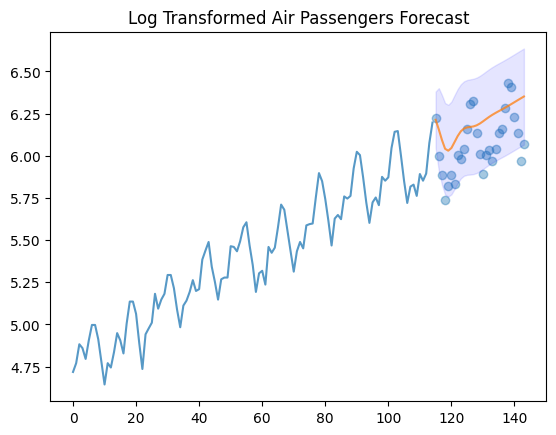

In [ ]:
x_axis = np.arange(ap_transformed_train.shape[0] + preds.shape[0]) # 115 + 29, plot을 그리기 위해 x축을 생성합니다. # 0
plt.plot(x_axis[:ap_transformed_train.shape[0]],ap_transformed_train, alpha=0.75) # 1
plt.plot(x_axis[ap_transformed_train.shape[0]:], preds, alpha=0.75) # 2
plt.scatter(x_axis[ap_transformed_train.shape[0]:],ap_transformed_test, 
            alpha=0.4, marker='o')  # 3 기존 test data는 scatter
plt.fill_between(x_axis[-preds.shape[0]:],
                 conf_int[:, 0], conf_int[:, 1],
                 alpha=0.1, color='b') # 4
plt.title("Log Transformed Air Passengers Forecast") # plot의 제목
plt.show() # 4개의 plot을 시각화 합니다.

## ARCH 모델 테스트

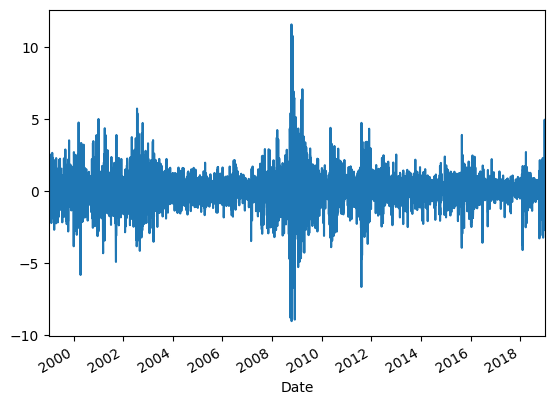

In [34]:
# 데이터 및 라이브러리 불러오기 
import datetime as dt # 날짜와 시간을 조작할 수 있는 Python 라이브러리
import arch.data.sp500 # S&P 500 데이터셋을 arch에서 불러오기

# 필요한 데이터로 가공하고 시각화를 통해 확인하기
st = dt.datetime(2002, 1, 1) # start date
en = dt.datetime(2022, 1, 1) # end date
data = arch.data.sp500.load() # s&p 500 데이터 불러오기
market = data["Adj Close"] # 종가만 활용
returns = 100 * market.pct_change().dropna() # return값으로 변환
ax = returns.plot() # 수익률을 그래프로 만들기
xlim = ax.set_xlim(returns.index.min(), returns.index.max()) # xlim은 x축 값의 보기를 제한 합니다. 
plt.show()

조건부 이분산성(Conditional Heteroskedasticity)이 나타났다.

- 분산이 특정 시점 이후 커졌다 작아졌다 하는 것
- 변동성 군집이 중앙에 나타났다.
- ARIMA 모델의 경우 분산이 일정하다고 가정하기 때문에, 이런 패턴이 있으면 예측 신뢰구간이 부정확해진다.
- 따라서 ARCH & GARCH를 적용해본다.


In [36]:
# ARCH 모델 적용
from arch import arch_model

am = arch_model(returns) # return을 arch모델에 적합
res = am.fit(update_freq=5)

# 지표를 통한 결과 확인
print(res.summary())

Iteration:      5,   Func. Count:     35,   Neg. LLF: 6970.276324897703
Iteration:     10,   Func. Count:     63,   Neg. LLF: 6936.718477482349
Optimization terminated successfully    (Exit mode 0)
            Current function value: 6936.718476989
            Iterations: 11
            Function evaluations: 68
            Gradient evaluations: 11
                     Constant Mean - GARCH Model Results                      
Dep. Variable:              Adj Close   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -6936.72
Distribution:                  Normal   AIC:                           13881.4
Method:            Maximum Likelihood   BIC:                           13907.5
                                        No. Observations:                 5030
Date:                Thu, Apr 16 2026   Df Residuals:                     5029
Time:             

- 다양한 결과가 제시되어있으나, 수업때 배웠던 p-value, AIC, BIC위주로 내용을 파악
- 아래에 있는 volatility model을 보면 alpha[1], Beta[1]은 GARCH(1,1)을 의미하며, p-value를 통해 신뢰도 95%에서 이들이 유의미함을 도출

- 표준화 잔차(Standardized Residuals) : GARCH 모델이 데이터를 설명하고 남은 잔차를 시각화 -> 평균 0, 분산 1 근처에서 몇몇 이상치를 제외하고 균일하게 분포
- 조건부 변동성(Conditional Volatility) : GARCH가 포착한 분산의 변화로, 2008년 금융위기 변동성을 모델이 잡았다.

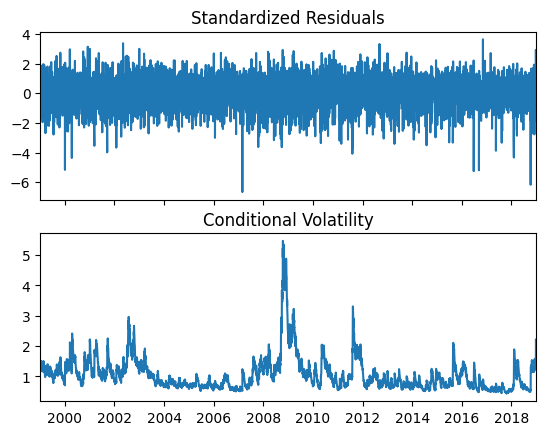

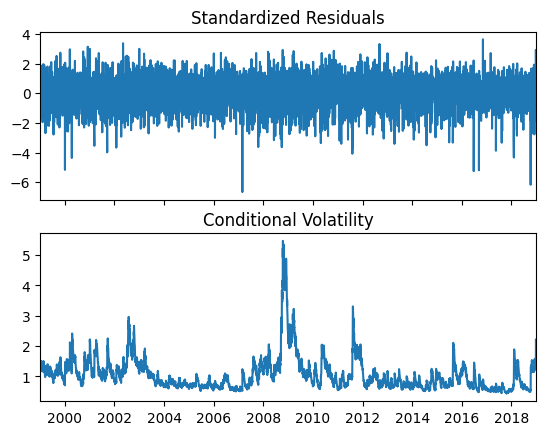

In [37]:
res.plot()